In [1]:
import requests
import pandas as pd

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "A191RL1Q225SBEA",
    "api_key": "4c68fd37456d1706c93321651fd0efa5",
    "file_type": "json"
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    # Convert observations to a DataFrame
    df = pd.DataFrame(data['observations'])
    
    # Clean up the data
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df.set_index('date', inplace=True)
    
    print(df.tail())
else:
    print(f"Error: {response.status_code}, {response.text}")

           realtime_start realtime_end  value
date                                         
2024-10-01     2026-03-13   2026-03-13    1.9
2025-01-01     2026-03-13   2026-03-13   -0.6
2025-04-01     2026-03-13   2026-03-13    3.8
2025-07-01     2026-03-13   2026-03-13    4.4
2025-10-01     2026-03-13   2026-03-13    0.7


In [13]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Prepare the GDP growth series ──────────────────────────────────────────
gdp = df[['value']].copy().dropna()
gdp.index = pd.to_datetime(gdp.index)
gdp = gdp.sort_index()
gdp.rename(columns={'value': 'gdp_growth'}, inplace=True)

print(f"Series length: {len(gdp)} quarters ({gdp.index[0].date()} → {gdp.index[-1].date()})")
gdp.tail()

Series length: 315 quarters (1947-04-01 → 2025-10-01)


,gdp_growth
date,
2024-10-01,1.9
2025-01-01,-0.6
2025-04-01,3.8
2025-07-01,4.4
2025-10-01,0.7


In [14]:
# ── 2. Feature engineering — autoregressive lags ─────────────────────────────
N_LAGS = 4   # four quarters of lags (one full year)

for lag in range(1, N_LAGS + 1):
    gdp[f'lag_{lag}'] = gdp['gdp_growth'].shift(lag)

gdp.dropna(inplace=True)

feature_cols = [f'lag_{i}' for i in range(1, N_LAGS + 1)]
target_col   = 'gdp_growth'

X = gdp[feature_cols].values
y = gdp[target_col].values

print(f"Feature matrix: {X.shape}  |  features: {feature_cols}")
gdp.head()

Feature matrix: (311, 4)  |  features: ['lag_1', 'lag_2', 'lag_3', 'lag_4']


,gdp_growth,lag_1,lag_2,lag_3,lag_4
date,,,,,
1948-04-01,6.8,6.2,6.4,-0.8,-1.0
1948-07-01,2.3,6.8,6.2,6.4,-0.8
1948-10-01,0.5,2.3,6.8,6.2,6.4
1949-01-01,-5.4,0.5,2.3,6.8,6.2
1949-04-01,-1.4,-5.4,0.5,2.3,6.8


In [22]:
# ── 3. Train / test split (cutoff: 2021 Q1, so COVID quarters stay in train) ──
SPLIT_DATE = '2021-01-01'

split_idx = gdp.index.searchsorted(SPLIT_DATE)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = gdp.index[:split_idx]
dates_test  = gdp.index[split_idx:]

print(f"Train: {len(X_train)} obs  ({dates_train[0].date()} → {dates_train[-1].date()})")
print(f"Test : {len(X_test)}  obs  ({dates_test[0].date()}  → {dates_test[-1].date()})")
print(f"Test share: {len(X_test)/len(X)*100:.1f}%")

Train: 291 obs  (1948-04-01 → 2020-10-01)
Test : 20  obs  (2021-01-01  → 2025-10-01)
Test share: 6.4%


In [23]:
# ── 4. Rolling-window cross-validation on the training set ────────────────────
# TimeSeriesSplit respects temporal order: each fold's test set is always
# strictly after its training set (expanding window).

N_SPLITS = 5   # number of CV folds

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

rf_cv = RandomForestRegressor(n_estimators=200, random_state=42)

cv_rmse, cv_mae = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    rf_cv.fit(X_tr, y_tr)
    y_pred_val = rf_cv.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae  = mean_absolute_error(y_val, y_pred_val)
    cv_rmse.append(rmse)
    cv_mae.append(mae)
    print(f"  Fold {fold}  |  train={len(X_tr):3d}  val={len(X_val):2d}  |  RMSE={rmse:.3f}  MAE={mae:.3f}")

print(f"\nCV mean RMSE : {np.mean(cv_rmse):.3f} ± {np.std(cv_rmse):.3f}")
print(f"CV mean MAE  : {np.mean(cv_mae):.3f} ± {np.std(cv_mae):.3f}")

  Fold 1  |  train= 51  val=48  |  RMSE=4.382  MAE=3.351
  Fold 2  |  train= 99  val=48  |  RMSE=4.837  MAE=3.654
  Fold 3  |  train=147  val=48  |  RMSE=2.270  MAE=1.788
  Fold 4  |  train=195  val=48  |  RMSE=2.748  MAE=2.059
  Fold 5  |  train=243  val=48  |  RMSE=6.966  MAE=3.176

CV mean RMSE : 4.241 ± 1.668
CV mean MAE  : 2.806 ± 0.741


In [24]:
# ── 5. Final model — train on full training set, evaluate on test set ─────────
rf_final = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X_train, y_train)

y_pred_test = rf_final.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)

print("─" * 40)
print(f"Out-of-sample RMSE : {test_rmse:.3f}")
print(f"Out-of-sample MAE  : {test_mae:.3f}")
print("─" * 40)

# Feature importance
importances = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances.to_string())

────────────────────────────────────────
Out-of-sample RMSE : 2.597
Out-of-sample MAE  : 2.321
────────────────────────────────────────

Feature importances:
lag_1    0.458463
lag_2    0.216910
lag_4    0.189347
lag_3    0.135280


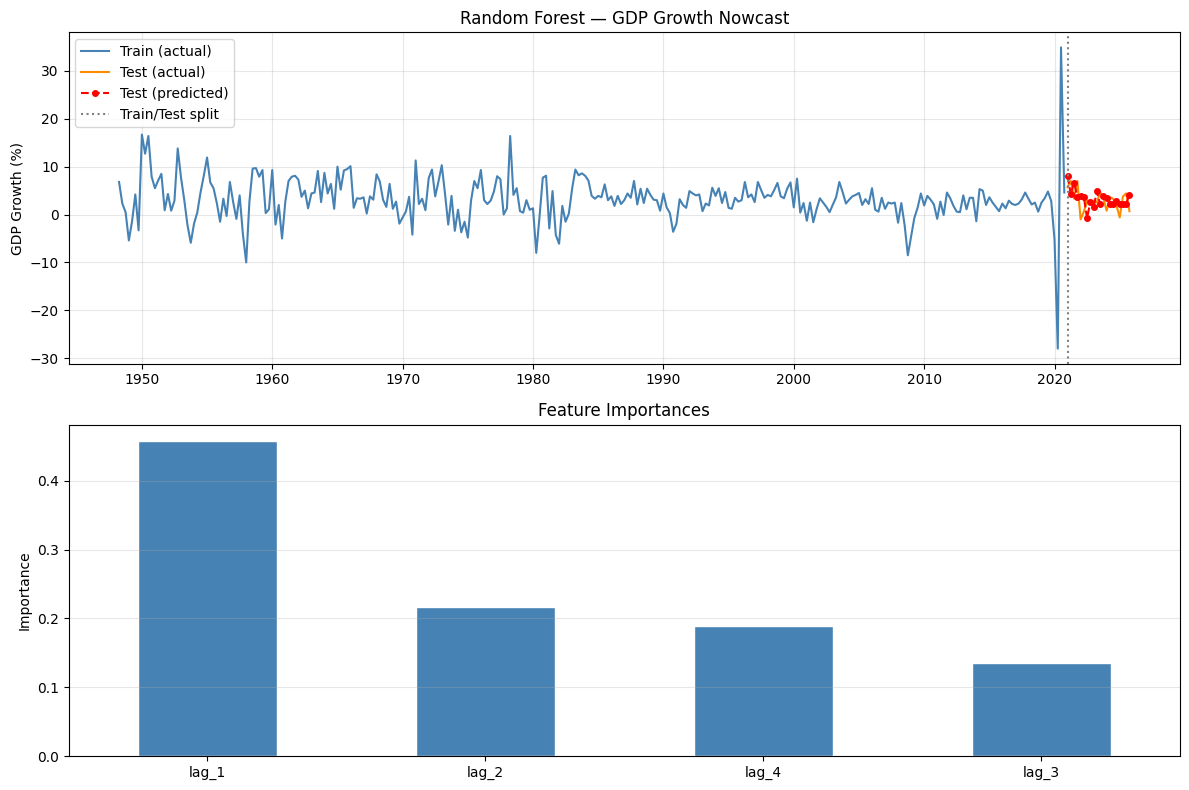

In [25]:
# ── 6. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# (a) Full series with train/test split
ax = axes[0]
ax.plot(dates_train, y_train, label='Train (actual)', color='steelblue')
ax.plot(dates_test,  y_test,  label='Test (actual)',  color='darkorange')
ax.plot(dates_test,  y_pred_test, label='Test (predicted)', color='red', linestyle='--', marker='o', markersize=4)
ax.axvline(dates_test[0], color='grey', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('Random Forest — GDP Growth Nowcast')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Feature importances
ax2 = axes[1]
importances.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Feature Importances')
ax2.set_ylabel('Importance')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Improved Models with COVID Dummies
Two dummies are added to account for the opposing COVID shocks:
- **`covid_crash`** = 1 for 2020 Q2 (GDP ~−28%), else 0
- **`covid_rebound`** = 1 for 2020 Q3 (GDP ~+35%), else 0

> **Note:** To improve the model by including the COVID Dummies, I decrease the size of the testing dataset so that the training dataset can include the COVID data. 

In [26]:
# ── 7. Build COVID-augmented feature matrix ───────────────────────────────────
gdp_covid = gdp.copy()   # gdp already has lag_1..lag_4 from earlier cells

gdp_covid['covid_crash']   = (gdp_covid.index == '2020-04-01').astype(int)  # Q2 2020
gdp_covid['covid_rebound'] = (gdp_covid.index == '2020-07-01').astype(int)  # Q3 2020

feature_cols_covid = [f'lag_{i}' for i in range(1, N_LAGS + 1)] + ['covid_crash', 'covid_rebound']

X_covid = gdp_covid[feature_cols_covid].values
y_covid = gdp_covid[target_col].values

# Same date-based split — COVID quarters now fall inside training
split_idx_c = gdp_covid.index.searchsorted(SPLIT_DATE)

X_train_c, X_test_c = X_covid[:split_idx_c], X_covid[split_idx_c:]
y_train_c, y_test_c = y_covid[:split_idx_c], y_covid[split_idx_c:]
dates_train_c = gdp_covid.index[:split_idx_c]
dates_test_c  = gdp_covid.index[split_idx_c:]

# Confirm COVID quarters are now in the training set
print("COVID dummies in training set:")
print(gdp_covid.loc[dates_train_c, ['gdp_growth', 'covid_crash', 'covid_rebound']].query('covid_crash==1 or covid_rebound==1'))
print(f"\nTrain: {len(X_train_c)} obs  ({dates_train_c[0].date()} → {dates_train_c[-1].date()})")
print(f"Test : {len(X_test_c)}  obs  ({dates_test_c[0].date()}  → {dates_test_c[-1].date()})")

COVID dummies in training set:
            gdp_growth  covid_crash  covid_rebound
date                                              
2020-04-01       -28.0            1              0
2020-07-01        34.9            0              1

Train: 291 obs  (1948-04-01 → 2020-10-01)
Test : 20  obs  (2021-01-01  → 2025-10-01)


In [27]:
# ── 8. Improved Random Forest with COVID dummies ──────────────────────────────
tscv_c = TimeSeriesSplit(n_splits=N_SPLITS)
rf_cv_c = RandomForestRegressor(n_estimators=200, random_state=42)

cv_rmse_c, cv_mae_c = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv_c.split(X_train_c), start=1):
    X_tr, X_val = X_train_c[tr_idx], X_train_c[val_idx]
    y_tr, y_val = y_train_c[tr_idx], y_train_c[val_idx]

    rf_cv_c.fit(X_tr, y_tr)
    y_pred_val = rf_cv_c.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae  = mean_absolute_error(y_val, y_pred_val)
    cv_rmse_c.append(rmse)
    cv_mae_c.append(mae)
    print(f"  Fold {fold}  |  train={len(X_tr):3d}  val={len(X_val):2d}  |  RMSE={rmse:.3f}  MAE={mae:.3f}")

print(f"\nCV mean RMSE : {np.mean(cv_rmse_c):.3f} ± {np.std(cv_rmse_c):.3f}")
print(f"CV mean MAE  : {np.mean(cv_mae_c):.3f} ± {np.std(cv_mae_c):.3f}")

# Final model
rf_final_c = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final_c.fit(X_train_c, y_train_c)
y_pred_test_c = rf_final_c.predict(X_test_c)

test_rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_test_c))
test_mae_c  = mean_absolute_error(y_test_c, y_pred_test_c)

importances_c = pd.Series(rf_final_c.feature_importances_, index=feature_cols_covid).sort_values(ascending=False)

print("\n" + "─" * 50)
print(f"{'':30s} {'Baseline':>8}  {'+ COVID':>8}")
print("─" * 50)
print(f"{'Out-of-sample RMSE':30s} {test_rmse:>8.3f}  {test_rmse_c:>8.3f}")
print(f"{'Out-of-sample MAE':30s} {test_mae:>8.3f}  {test_mae_c:>8.3f}")
print("─" * 50)
print("\nFeature importances (RF + COVID dummies):")
print(importances_c.to_string())

  Fold 1  |  train= 51  val=48  |  RMSE=4.401  MAE=3.342
  Fold 2  |  train= 99  val=48  |  RMSE=4.861  MAE=3.693
  Fold 3  |  train=147  val=48  |  RMSE=2.240  MAE=1.759
  Fold 4  |  train=195  val=48  |  RMSE=2.777  MAE=2.084
  Fold 5  |  train=243  val=48  |  RMSE=6.947  MAE=3.160

CV mean RMSE : 4.245 ± 1.666
CV mean MAE  : 2.808 ± 0.751

──────────────────────────────────────────────────
                               Baseline   + COVID
──────────────────────────────────────────────────
Out-of-sample RMSE                2.597     2.556
Out-of-sample MAE                 2.321     2.274
──────────────────────────────────────────────────

Feature importances (RF + COVID dummies):
lag_1            0.336333
lag_4            0.182115
lag_2            0.180969
covid_crash      0.140242
lag_3            0.115332
covid_rebound    0.045009


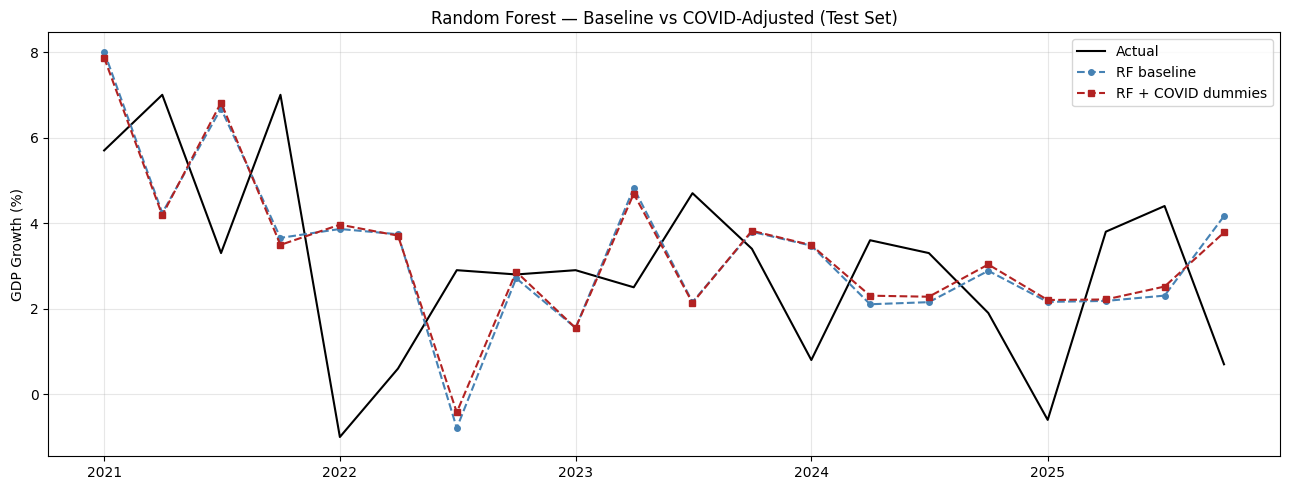

In [33]:
# ── 9. Visualisation — baseline vs COVID-adjusted predictions ────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(dates_test_c, y_test_c,       label='Actual',             color='black',     linewidth=1.5)
ax.plot(dates_test_c, y_pred_test,    label='RF baseline',        color='steelblue', linestyle='--', marker='o', markersize=4)
ax.plot(dates_test_c, y_pred_test_c,  label='RF + COVID dummies', color='firebrick', linestyle='--', marker='s', markersize=4)
ax.set_title('Random Forest — Baseline vs COVID-Adjusted (Test Set)')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()